<a href="https://colab.research.google.com/github/nattapongbam/Rainfall-Forecasting-ChiangMai/blob/main/HOLD_WINTER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sktime

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib as mpl
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.model_selection import ForecastingGridSearchCV, ExpandingWindowSplitter

In [ ]:
df = pd.read_csv('weather.csv', parse_dates=['Unnamed: 0'])
df.rename(columns={'Unnamed: 0':'date', 'rain':'Rain'}, inplace=True)
df.set_index('date', inplace=True)
df

,wind_dir,wind_speed,temp,heat_index,pressure,preci,vis,Rain
date,,,,,,,,
2013-01-01,297.0,1.10,22.25,24.45,977.15,5.5,13249.0,0.81
2013-02-01,289.0,1.25,24.85,25.85,973.75,0.1,13433.0,1.13
2013-03-01,334.0,0.50,28.10,28.10,972.40,0.0,7735.0,0.55
2013-04-01,176.0,1.40,31.70,32.50,970.50,0.4,12949.0,0.04
2013-05-01,193.0,1.80,29.90,32.60,970.30,100.0,18706.0,2.90
...,...,...,...,...,...,...,...,...
2024-08-01,230.0,1.50,27.60,31.20,970.80,232.2,18911.0,7.67
2024-09-01,249.0,1.50,27.50,31.00,969.80,389.6,19995.0,12.75
2024-10-01,277.0,1.50,27.70,30.90,974.00,149.6,19993.0,4.66


In [ ]:
# กำหนดค่าเพดานไว้ที่ 12
# df['rain'] = train1['Rain'].apply(lambda x: 12 if x > 12 else x)
df['rain'] = df['Rain'].apply(lambda x: 12 if x > 12 else x)

In [ ]:
df = df.iloc[:-12]

In [ ]:
train = df.iloc[:-12].copy()
test = df.iloc[-12:].copy()

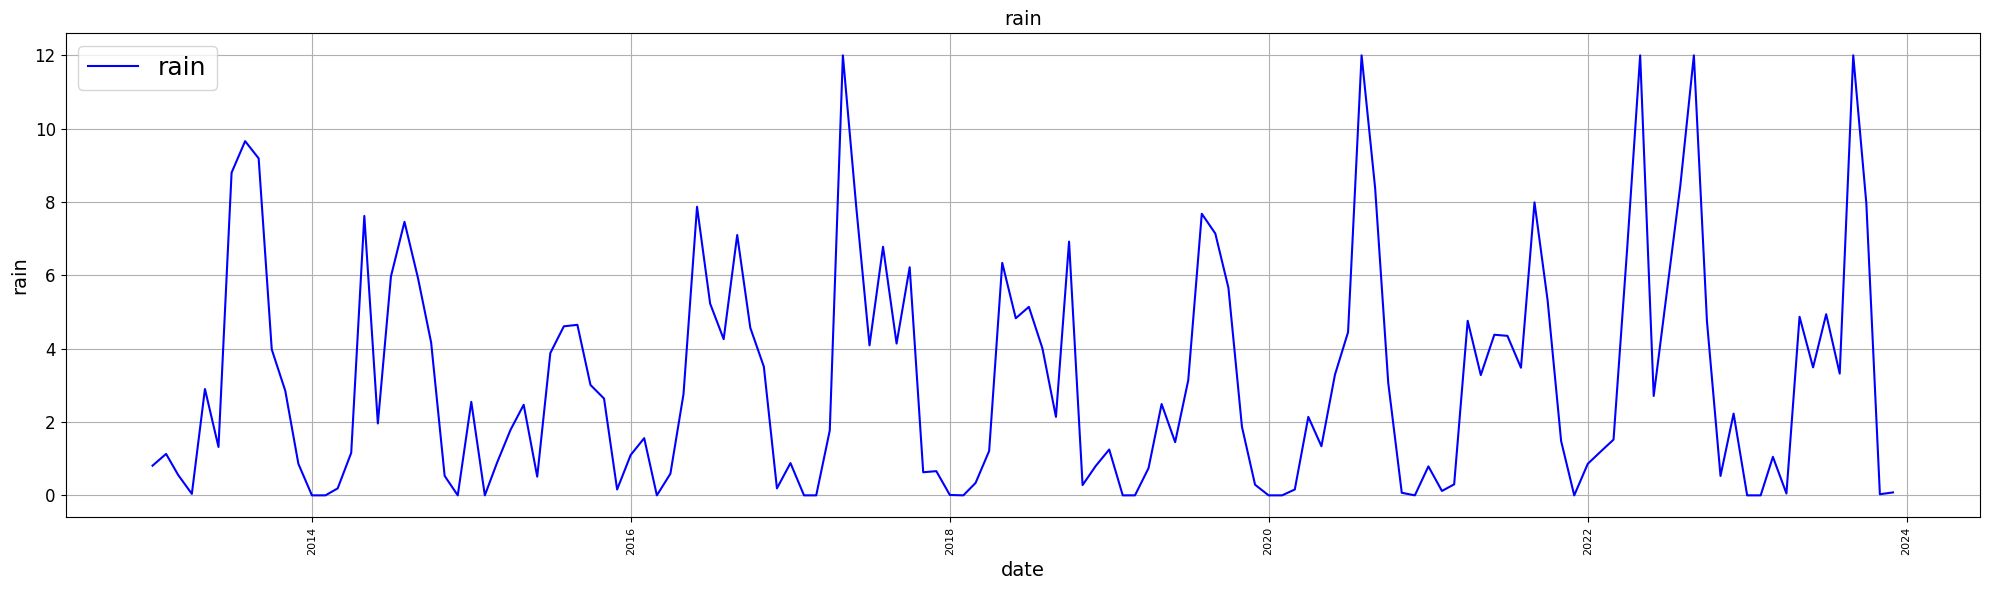

In [ ]:
plt.figure(figsize=(20,6))
plt.plot(df.index, df['rain'], label='rain', color='blue')
plt.legend(fontsize=18)
plt.title('rain', fontsize=14)
plt.xlabel('date', fontsize=14)
plt.ylabel('rain', fontsize=14)
plt.grid(True)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
train['rain'].asfreq('MS')

,rain
date,
2013-01-01,0.81
2013-02-01,1.13
2013-03-01,0.55
2013-04-01,0.04
2013-05-01,2.90
...,...
2022-08-01,8.45
2022-09-01,12.00
2022-10-01,4.74


In [ ]:
train['rain'].index = train['rain'].index.to_period('M')

In [ ]:
from sktime.forecasting.model_selection import ForecastingGridSearchCV, ExpandingWindowSplitter
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.performance_metrics.forecasting import MeanSquaredError, MeanAbsoluteError

fh = np.arange(1, 13)

cv = ExpandingWindowSplitter(
    initial_window=60,
    step_length=12,
    fh=fh
)

params = {
    "trend": ['add', "mul"],
    "seasonal": ['add', "mul"],
    "damped_trend": [True],
    "use_boxcox": [True],
    "initialization_method": ["legacy-heuristic"],
    'smoothing_level' : [0.0001],
    'smoothing_trend' : [0.001],
    'smoothing_seasonal' : [0.3]
}

gscv = ForecastingGridSearchCV(
    forecaster=ExponentialSmoothing(sp=12),
    param_grid=params,
    cv=cv,
    strategy="refit",
    scoring=MeanSquaredError(square_root=True),
    error_score='raise'
)

gscv.fit(train['rain']+0.00001)

print(f"Best Parameters: {gscv.best_params_}")
# print(f"Best Score: {gscv.best_score_}")

Best Parameters: {'damped_trend': True, 'initialization_method': 'legacy-heuristic', 'seasonal': 'add', 'smoothing_level': 0.0001, 'smoothing_seasonal': 0.3, 'smoothing_trend': 0.001, 'trend': 'mul', 'use_boxcox': True}


<Figure size 1500x600 with 0 Axes>

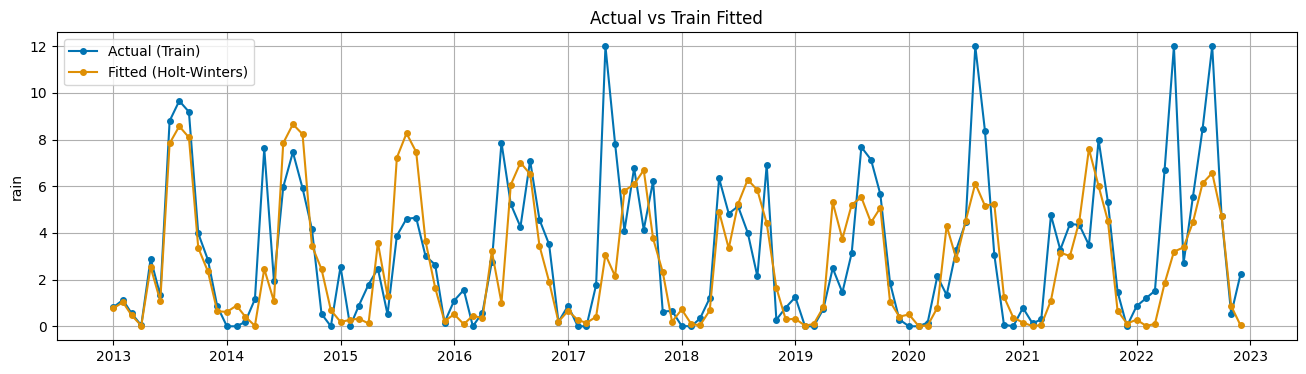

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sktime.utils.plotting import plot_series

fh_train = np.arange(-len(train['rain']) + 1, 1)
y_fitted_train = gscv.predict(fh=fh_train)

plt.figure(figsize=(15, 6))
plot_series(train['rain'], y_fitted_train, labels=["Actual (Train)", "Fitted (Holt-Winters)"])
plt.title("Actual vs Train Fitted")
ax = plt.gca() # Get the current axes
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.grid(True)
plt.show()

# train

In [ ]:
y_actual_12th = train['rain'].iloc[-12:] ##train
fh_check = np.arange(-11, 1)
y_pred_adj_check = gscv.predict(fh=fh_check)
if hasattr(y_pred_adj_check.index, 'to_timestamp'):
    y_pred_adj_check.index = y_pred_adj_check.index.to_timestamp()


In [ ]:
rmse = MeanSquaredError(square_root=True)  ##train
rmse_val = rmse(y_actual_12th, y_pred_adj_check)

mse = MeanSquaredError()
mse_val = mse(y_actual_12th, y_pred_adj_check)

mae = MeanAbsoluteError()
mae_val = mae(y_actual_12th, y_pred_adj_check)

print(f"RMSE: {rmse_val.round(4)}")
print(f"MSE: {mse_val.round(4)}")
print(f"MAE: {mae_val.round(4)}")

from sklearn.metrics import r2_score

r2 = r2_score(y_actual_12th, y_pred_adj_check)
print(f"R2 Score: {r2:.4f}")

RMSE: 3.4918
MSE: 12.1925
MAE: 2.4084
R2 Score: 0.2277


/usr/local/lib/python3.12/dist-packages/sktime/performance_metrics/forecasting/_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


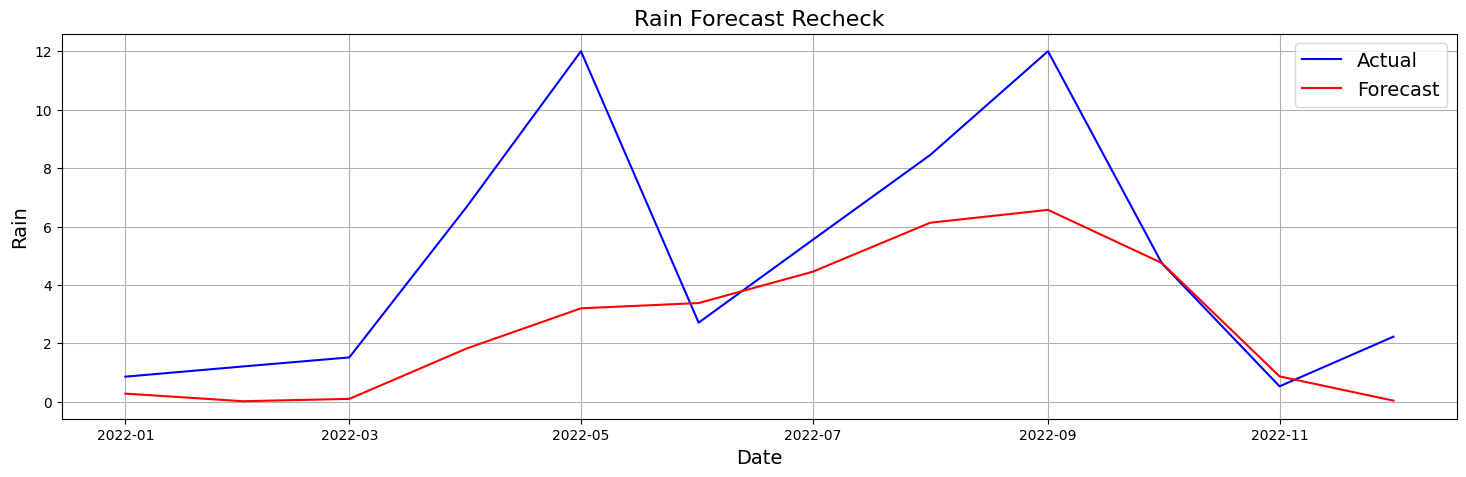

In [ ]:
plt.figure(figsize=(18, 5))
if hasattr(y_actual_12th.index, 'to_timestamp'):
    y_actual_12th.index = y_actual_12th.index.to_timestamp()
plt.plot(y_actual_12th.index, y_actual_12th, label='Actual', color='blue')
plt.plot(y_pred_adj_check.index, y_pred_adj_check.round(2), label='Forecast', color='red') #y_pred_doubltFit.index.to_timestamp()
plt.title('Rain Forecast Recheck', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Rain', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

# Test

In [ ]:
fh_test = np.arange(1, len(test) + 1)
y_pred = gscv.predict(fh=fh_test)

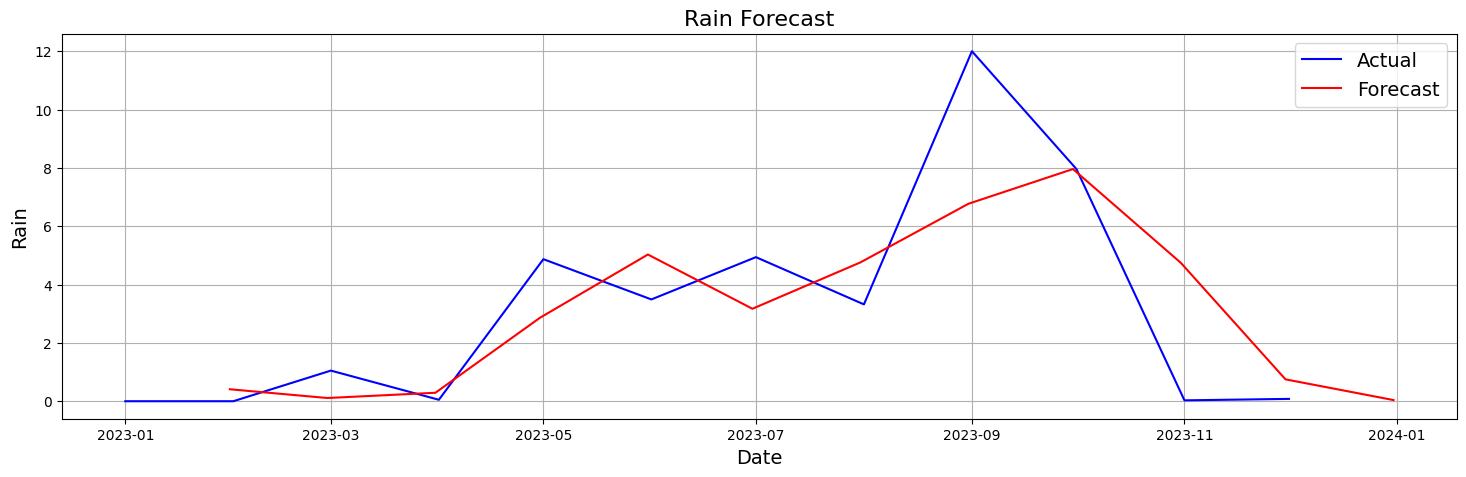

In [ ]:
plt.figure(figsize=(18, 5))
plt.plot(test.index, test['rain'], label='Actual', color='blue')
plt.plot(y_pred.index, y_pred.round(2), label='Forecast', color='red') #y_pred_doubltFit.index.to_timestamp()
plt.title('Rain Forecast', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Rain', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

In [ ]:
rmse = MeanSquaredError(square_root=True)
rmse_test = rmse(test['rain'], y_pred)

mse = MeanSquaredError()
mse_test = mse(test['rain'], y_pred)

mae = MeanAbsoluteError()
mae_test = mae(test['rain'], y_pred)

print(f"RMSE: {rmse_test.round(4)}")
print(f"MSE: {mse_test.round(4)}")
print(f"MAE: {mae_test.round(4)}")

from sklearn.metrics import r2_score

r2 = r2_score(test['rain'], y_pred)
print(f"R2 Score: {r2:.4f}")

RMSE: 1.9968
MSE: 3.9872
MAE: 1.3507
R2 Score: 0.7024


/usr/local/lib/python3.12/dist-packages/sktime/performance_metrics/forecasting/_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(
